In [1]:
# load module
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorboard as tb 
import pytorch_lightning as pl
from itertools import product

from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from IPython.core.display import HTML

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs_nei import *
from tqdm import tqdm

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [2]:
def k_nbrs_in(G, start, k):
    nbrs = set([start])
    for l in range(k):
        nbrs = set((nbr for n in nbrs for nbr in G[n]))
    return nbrs  | set([start])

def k_nbrs(G, start, k):
    nbrs = set([start])
    for l in range(k):
        nbrs = set((nbr for n in nbrs for nbr in G[n]))
    return nbrs 

In [3]:
def graph_count(graph_data : pd.DataFrame, w1 : float , w2 : float , w3 : float):
    nei_dong = {
    '동산면' : ['동내면' , '신동면', '남산면'],
    '후평1동' :['동  면' , '신사우동', '근화동', '소양동', '교  동', ],
    '사북면' : ['서  면' , '신북읍'],
    '신북읍' : ['북산면' , '사북면' , '서  면', '신사우동' , '동  면'], 
    '석사동' : ['동내면', '동  면', '퇴계동'],
    '남산면' : ['동산면', '신동면', '서  면' , '남  면'],
    '교  동' : ['후평1동' , '소양동' , '조운동' , ],
    '신동면' : ['동내면' , '퇴계동', '강남동', '서  면', '남산면', '동산면'],
    '효자1동': ['조운동', '약사명동','근화동','강남동', '퇴계동', ],
    '북산면' : ['신북읍', '동  면'],
    '서  면' : ['신사우동', '신북읍', '사북면', '남산면', '신동면', '강남동', '근화동'],
    '조운동' : ['교  동', '소양동' , '약사명동', '효자1동'],
    '동내면' : ['동  면', '석사동', '퇴계동', '신동면' , '동산면'],
    '강남동' : ['퇴계동', '효자1동', '근화동','서  면' , '신동면'],
    '퇴계동' : ['석사동', '강남동', '신동면'],
    '근화동' : ['신사우동' , '서  면' , '강남동', '약사명동', '소양동'] , 
    '동  면' : ['북산면' , '신북읍', '신사우동', '후평1동' , '석사동' , '동내면'],
    '신사우동':['동  면' , '신북읍','서  면' , '근화동' , '후평1동'],
    '약사명동':['소양동' , '근화동','효자1동', '조운동'],
    '남  면' : ['남산면'],
    '북산면' : ['신북읍' , '동  면'],
    '소양동' : ['근화동', '후평1동' , '교  동' , '조운동' , '약사명동']
    }

    graph_data = graph_data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd' , 'humid' , 'temp', 'precip_form', 'precip', 'isHoliday']]
    dongs = graph_data['h_dong'].unique()
    
    nei_edge_df = pd.DataFrame(columns = ['source' , 'target' , 'weight'])

    idx = 0
    for key in nei_dong.keys():
        for nei in nei_dong[key]:
            nei_edge_df.loc[idx] = [key, nei , 1 ,]
            idx += 1
    nei_node_df = pd.DataFrame(
        {
        'adm' : dongs,
        'color' : np.full(len(dongs) , 'yellow' )
    })
    
    adm_G = nx.from_pandas_edgelist(nei_edge_df , source='source' , target='target' , edge_attr = ['weight'])
    nodes_attr = nei_node_df.set_index('adm').to_dict(orient='index')
    nx.set_node_attributes(adm_G, nodes_attr)
    dts = graph_data['REG_DTIME'].unique()#.astype(str)
    dongs = graph_data['h_dong'].unique()
    for dong in tqdm(graph_data['h_dong'].unique()):
        dong_df = graph_data[graph_data['h_dong'] == dong]
        nei_dongs = k_nbrs(adm_G, dong, 1)
        nei_sum = np.full(len(dong_df), 0)
        for nei_dong in nei_dongs:
            nei_count = graph_data[graph_data['h_dong'] == nei_dong]['count'].to_list()
            nei_sum += nei_count
        graph_data.loc[dong_df.index, 'nei1'] = (w1*dong_df['count'].to_list()) + (w2*nei_sum)
    return graph_data

100%|██████████| 21/21 [00:00<00:00, 751.09it/s]


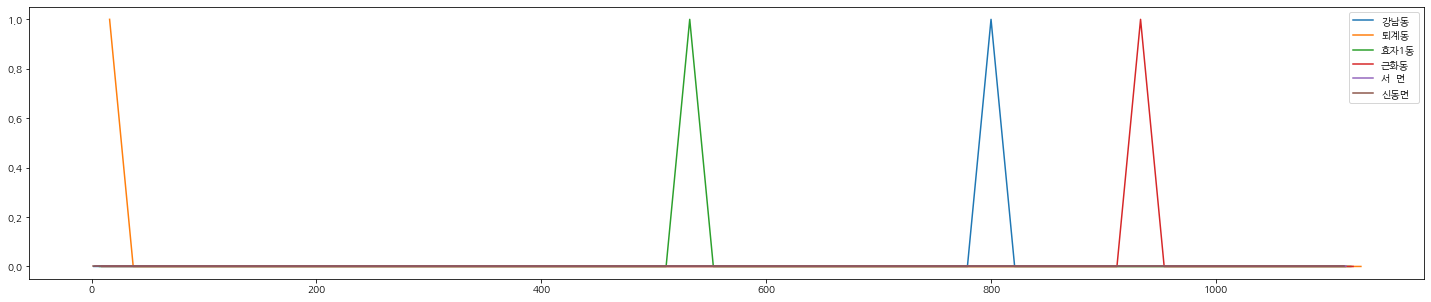

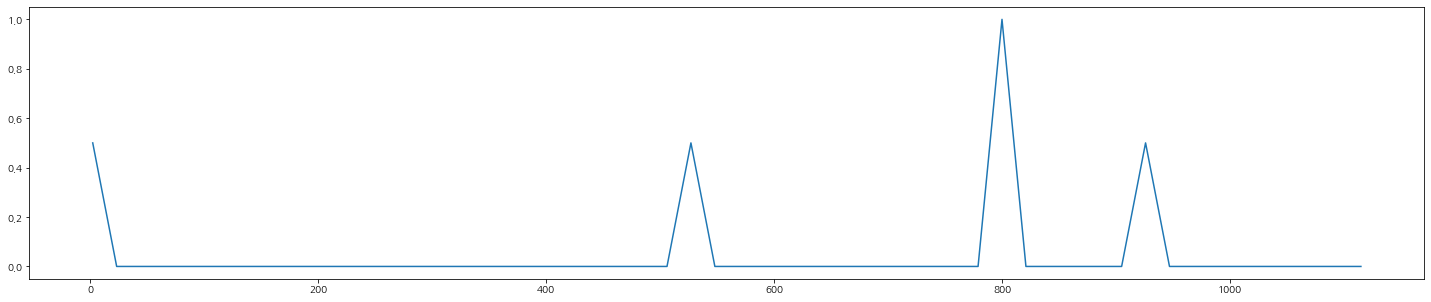

In [20]:
data = pd.read_csv('../../data/2016_2021.csv')
data = data[: 21*54]

fig = plt.figure(figsize=(25, 5))
plt.plot(data[data['h_dong'] =='강남동']['count'], label = '강남동')
plt.plot(data[data['h_dong'] =='퇴계동']['count'], label = '퇴계동')
plt.plot(data[data['h_dong'] =='효자1동']['count'], label = '효자1동')
plt.plot(data[data['h_dong'] =='근화동']['count'], label = '근화동')
plt.plot(data[data['h_dong'] =='서  면']['count'], label = '서  면')
plt.plot(data[data['h_dong'] =='신동면']['count'], label = '신동면')
plt.legend()

fig = plt.figure(figsize=(25, 5))
data = graph_count(data, 1, 0.5, 0)
plt.plot(data[data['h_dong'] =='강남동']['nei1'], label = '강남동')

In [8]:
data = pd.read_csv('../../data/2016_2021.csv')
data = graph_count(data, 1, 1, 0)
data

100%|██████████| 21/21 [00:04<00:00,  4.30it/s]


,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday,nei1
0,2016-01-01 01:00:00,석사동,0,39299.0,1.0,77.55,1.685,2.0,1.0,True,1.0
1,2016-01-01 01:00:00,신동면,0,2527.0,1.0,79.15,1.640,0.0,0.0,True,1.0
2,2016-01-01 01:00:00,강남동,0,16830.0,1.0,79.15,1.740,0.0,0.0,True,1.0
3,2016-01-01 01:00:00,서 면,0,4033.0,1.8,80.25,1.915,2.0,1.0,True,0.0
4,2016-01-01 01:00:00,남 면,0,1095.0,1.8,83.70,3.340,0.0,0.0,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1133974,2022-02-27 23:00:00,퇴계동,0,48681.0,0.7,80.00,0.800,0.0,0.0,False,0.0
1133975,2022-02-27 23:00:00,북산면,0,965.0,0.0,84.00,2.600,0.0,0.0,False,0.0
1133976,2022-02-27 23:00:00,조운동,0,2675.0,0.7,80.00,0.800,0.0,0.0,False,0.0
1133977,2022-02-27 23:00:00,동산면,0,1445.0,0.5,89.00,1.600,0.0,0.0,False,0.0


In [16]:
dt = pd.date_range('2016/01/01' ,'2022/01/01', freq='h')[:-1].astype(str)
train_data = data[data['REG_DTIME'].isin(dt)]
train_data

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday,nei1
0,2016-01-01 01:00:00,석사동,0,39299.0,1.0,77.55,1.685,2.0,1.0,True,1.0
1,2016-01-01 01:00:00,신동면,0,2527.0,1.0,79.15,1.640,0.0,0.0,True,1.0
2,2016-01-01 01:00:00,강남동,0,16830.0,1.0,79.15,1.740,0.0,0.0,True,1.0
3,2016-01-01 01:00:00,서 면,0,4033.0,1.8,80.25,1.915,2.0,1.0,True,0.0
4,2016-01-01 01:00:00,남 면,0,1095.0,1.8,83.70,3.340,0.0,0.0,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1104742,2021-12-31 23:00:00,근화동,0,8540.0,0.7,72.00,-12.400,0.0,0.0,False,2.0
1104743,2021-12-31 23:00:00,동 면,0,19649.0,0.7,72.00,-12.400,0.0,0.0,False,0.0
1104744,2021-12-31 23:00:00,신사우동,0,22935.0,0.7,72.00,-12.400,0.0,0.0,False,0.0
1104745,2021-12-31 23:00:00,약사명동,0,3278.0,0.7,72.00,-12.400,0.0,0.0,False,2.0


In [17]:
test_data = data[~data['REG_DTIME'].isin(dt)]
test_data

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday,nei1
1104747,2022-01-01 00:00:00,석사동,0,34593.0,1.4,60.0,-9.7,0.0,0.0,True,0.0
1104748,2022-01-01 00:00:00,신동면,0,2602.0,0.3,48.0,-8.6,0.0,0.0,True,0.0
1104749,2022-01-01 00:00:00,강남동,0,22607.0,1.4,60.0,-9.7,0.0,0.0,True,0.0
1104750,2022-01-01 00:00:00,서 면,0,3782.0,1.4,60.0,-9.7,0.0,0.0,True,0.0
1104751,2022-01-01 00:00:00,남 면,0,1073.0,0.3,48.0,-8.6,0.0,0.0,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1133974,2022-02-27 23:00:00,퇴계동,0,48681.0,0.7,80.0,0.8,0.0,0.0,False,0.0
1133975,2022-02-27 23:00:00,북산면,0,965.0,0.0,84.0,2.6,0.0,0.0,False,0.0
1133976,2022-02-27 23:00:00,조운동,0,2675.0,0.7,80.0,0.8,0.0,0.0,False,0.0
1133977,2022-02-27 23:00:00,동산면,0,1445.0,0.5,89.0,1.6,0.0,0.0,False,0.0
